# Variable og konstante krefter

In [5]:
from enum import Enum
import matplotlib.pyplot as plt

class måltall():
    def __init__(self, id, navn, symbol, enhet):
        self.id = id
        self.navn = navn
        self.symbol = symbol
        self.enhet = enhet

Akselerasjon_måltall = måltall(0, "Akselerasjon", "a", "m/s^2")
Fart_måltall = måltall(1, "Fart", "v", "m/s")
Strekning_måltall = måltall(2, "Posisjon", "s", "m")
Tid_måltall = måltall(3, "Tid", "t", "s")

class Storrelse(Enum):
    Akselerasjon = 0
    Fart = 1
    Strekning = 2
    Tid = 3

storrelser = {
    0 : Akselerasjon_måltall,
    1 : Fart_måltall,
    2 : Strekning_måltall,
    3 : Tid_måltall
}

## Verdier for simuleringer

In [6]:
from packaging._structures import Infinity

# informasjon om bevegelsen
s = 0
v = 0
t = 0

m = 79
g = 9.81
k = 0.32
G = m * g

# Simuleringsteknisk
s_slutt = 50
t_slutt = Infinity
dt = 0.01
s_verdier = [s]
v_verider = [v]
t_verdier = [t]

# akselerasjonsfunksjon

# a(v)
def a(v):
    L = k*v**2
    sum_F = G - L
    return sum_F/m

# a(t)

a_verdier = [a(s)]

# definer aksene
x_akse = Storrelse.Tid
y_akse = Storrelse.Strekning

print(x_akse)

Storrelse.Tid


simuleringslogikk

In [7]:
while s < s_slutt and t < t_slutt: # de ubrukte skal være inf
    v = v + a(v)*dt # husk å ha riktig her
    s = s + v*dt
    t = t + dt
    s_verdier.append(s)
    v_verider.append(v)
    t_verdier.append(t)
    a_verdier.append(a(v)) # husk å riktig her

Viser resultat på en graf

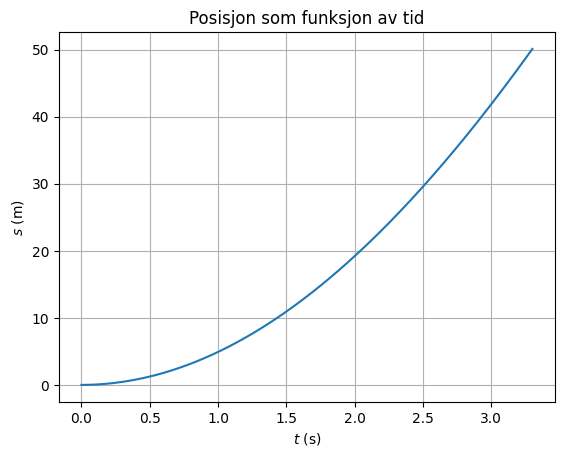

In [8]:
verider = [a_verdier, v_verider, s_verdier, t_verdier]

x_verier = verider[x_akse.value]
y_verier = verider[y_akse.value]

x_storrelse = storrelser[x_akse.value]
y_storrelse = storrelser[y_akse.value]

plt.plot(x_verier, y_verier)
plt.title(f"{y_storrelse.navn} som funksjon av {x_storrelse.navn.lower()}")
plt.xlabel(f"${x_storrelse.symbol}$ ({x_storrelse.enhet})")
plt.ylabel(f"${y_storrelse.symbol}$ ({y_storrelse.enhet})")
plt.grid()
plt.show()